In [120]:
from dotenv import load_dotenv
load_dotenv()

True

In [121]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters  import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_community.vectorstores import InMemoryVectorStore

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field


In [122]:
# Document Load
loader = PyPDFLoader("../data/Artificial Intelligence Overview.pdf")
docs  = loader.load()

# split document
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
split_docs = splitter.split_documents(docs)

# create embeddings
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview",)

# create vector store
vector_store = InMemoryVectorStore.from_documents(
    documents=split_docs, 
    embedding=embeddings,
    collection_name="rag_langraph_19_notebook"
    )

In [123]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [124]:
class RagState(BaseModel):
    question: str = Field(description="The question to be asked in the RAG system")
    document:list = []
    context: str = Field(default="", description="The context retrieved from the documents")
    answer: str = Field(default="", description="The answer generated by the RAG system")
    

In [125]:
# question -> docs retrieve -> context extraction -> answer generation

def retrieve_docs_node(state: RagState) -> RagState:
    print("[retrieve_node]: Starting document retrieval for question:", state.question)
    retrieved_docs = vector_store.similarity_search(state.question)
    state.document = retrieved_docs
    print("[retrieve_node]: Retrieved documents:", state.document , "\n\n")
    return state

In [126]:

def context_extraction_node(state: RagState) -> RagState:
    print("[context_extraction_node]: Extracting context from retrieved documents...")
    context = ""
    for doc in state.document:
        context += doc.page_content + "\n"
    state.context = context
    print("[context_extraction_node]: Context extracted:", state.context , "\n\n")
    return state

In [127]:
def generate_answer_node(state: RagState) -> RagState:
    print("[generate_answer_node]: Generating answer based on context:", state.context)
    prompt = """
        You are an assistant and provide the answer for the question based on the given context.
        dont make up an answer if the context does not contain the information. just say you don't know.
        question: {state.question},
        context: {state.context} 
    """
    response = llm.invoke(prompt)
    print("[generate_answer_node]: Response received:", response.content , "\n\n")
    state.answer = response.content
    return state

In [128]:
#  graph of the RAG pipeline: question -> docs retrieve -> context extraction -> answer generation
graph = StateGraph(RagState)

graph.add_node("retrieve_docs", retrieve_docs_node)
graph.add_node("extract_context", context_extraction_node)
graph.add_node("generate_answer", generate_answer_node)


graph.add_edge(START, "retrieve_docs")
graph.add_edge("retrieve_docs", "extract_context")
graph.add_edge("extract_context", "generate_answer")
graph.add_edge("generate_answer", END)

graph = graph.compile()

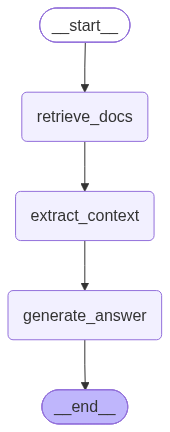

In [129]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png() )

In [130]:
res = graph.invoke({"question": "what this document is about"})

[retrieve_node]: Starting document retrieval for question: what this document is about
[retrieve_node]: Retrieved documents: [Document(id='ad827dee-d0a2-451c-8a75-772ac7f44485', metadata={'producer': 'Skia/PDF m136', 'creator': 'Chromium', 'creationdate': '2026-10-01T08:34:45+00:00', 'title': 'Artificial Intelligence: Executive Overview', 'moddate': '2026-10-01T08:34:45+00:00', 'source': '../data/Artificial Intelligence Overview.pdf', 'total_pages': 2, 'page': 1, 'page_label': '2'}, page_content='Artiﬁcial Intelligence Overview Page 1 of 1'), Document(id='cccf1adf-5ee7-4700-b53e-d7d533417ba6', metadata={'producer': 'Skia/PDF m136', 'creator': 'Chromium', 'creationdate': '2026-10-01T08:34:45+00:00', 'title': 'Artificial Intelligence: Executive Overview', 'moddate': '2026-10-01T08:34:45+00:00', 'source': '../data/Artificial Intelligence Overview.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='Artificial Intelligence\nA concise brieﬁng on architectural paradigms, indu

In [131]:
res["answer"][0]["text"]

"I don't know."